In [1]:
from pathlib import Path
import sys

# Go from notebooks/ to project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\MedVision-AI


# Notebook 09 – Model Evaluation

## Objectives

In this notebook, we evaluate the trained EfficientNet-B0 model using the unseen Chest X-ray test dataset.

This notebook includes:

- Loading the best trained model
- Running inference on the test set
- Computing evaluation metrics
- Generating the classification report
- Plotting the confusion matrix
- Plotting the ROC curve
- Visualizing sample predictions
- Saving evaluation results

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

In [3]:
from app.models.efficientnet import build_efficientnet_b0

from app.preprocessing.dataset import get_dataloaders
from app.preprocessing.transforms import (
    train_transform,
    val_transform,
)

from app.training.checkpoint import load_checkpoint

from app.evaluation import (
    evaluate_model,
    compute_metrics,
    generate_classification_report,
    print_evaluation_summary,
    save_predictions_csv,
    plot_confusion_matrix,
    plot_roc_curve,
)

c:\MedVision-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DATASET_PATH = Path("../dataset/chest_xray")

CHECKPOINT_DIR = Path("../checkpoints")

NUM_CLASSES = 2

In [5]:
_, _, test_loader = get_dataloaders(
    dataset_path=DATASET_PATH,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=32,
)

In [6]:
model = build_efficientnet_b0(
    num_classes=NUM_CLASSES,
    pretrained=False,
).to(DEVICE)

In [7]:
checkpoint = load_checkpoint(
    filepath=CHECKPOINT_DIR / "best_model.pth",
    model=model,
)

In [8]:
results = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=DEVICE,
)

In [9]:
results["labels"]
results["predictions"]
results["probabilities"]

array([4.42853719e-01, 2.57743783e-02, 3.76914233e-01, 3.43561143e-01,
       1.67729586e-01, 6.27850592e-02, 6.60096288e-01, 1.48673296e-01,
       6.78053677e-01, 6.28933087e-02, 3.30939472e-01, 9.03647542e-01,
       5.27914047e-01, 2.51391411e-01, 5.00241876e-01, 4.44569826e-01,
       9.89353418e-01, 5.51076949e-01, 1.90202162e-01, 5.55893362e-01,
       4.70202684e-01, 1.14002489e-01, 2.23379314e-01, 2.25537732e-01,
       2.12255176e-02, 1.36540845e-01, 7.54627585e-01, 4.91600960e-01,
       1.74949944e-01, 1.75623283e-01, 3.80950391e-01, 2.50464737e-01,
       2.50219285e-01, 3.99685174e-01, 7.20844626e-01, 7.67859537e-03,
       3.73050496e-02, 5.56619978e-03, 1.74444951e-02, 1.27645545e-02,
       4.26271498e-01, 7.47379707e-03, 2.32779887e-02, 4.87171533e-03,
       9.33055654e-02, 9.81268346e-01, 7.70298019e-02, 2.39994019e-01,
       7.87358060e-02, 2.86723942e-01, 1.29811883e-01, 1.98830049e-02,
       1.59303367e-01, 1.69418454e-02, 1.16227409e-02, 2.48246733e-02,
      

In [10]:
metrics = compute_metrics(
    y_true=results["labels"],
    y_pred=results["predictions"],
    y_prob=results["probabilities"],
)

print_evaluation_summary(metrics)

MODEL EVALUATION SUMMARY
Accuracy : 0.8734
Precision: 0.8659
Recall   : 0.9436
F1 Score : 0.9031
AUC      : 0.9375


In [11]:
print(
    generate_classification_report(
        results["labels"],
        results["predictions"],
    )
)

              precision    recall  f1-score   support

      Normal     0.8894    0.7564    0.8176       234
   Pneumonia     0.8659    0.9436    0.9031       390

    accuracy                         0.8734       624
   macro avg     0.8777    0.8500    0.8603       624
weighted avg     0.8747    0.8734    0.8710       624



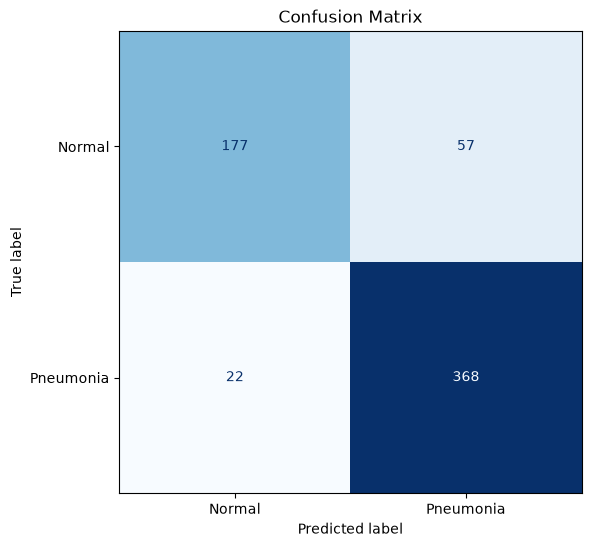

In [12]:
plot_confusion_matrix(
    results["labels"],
    results["predictions"],
)

plt.show()

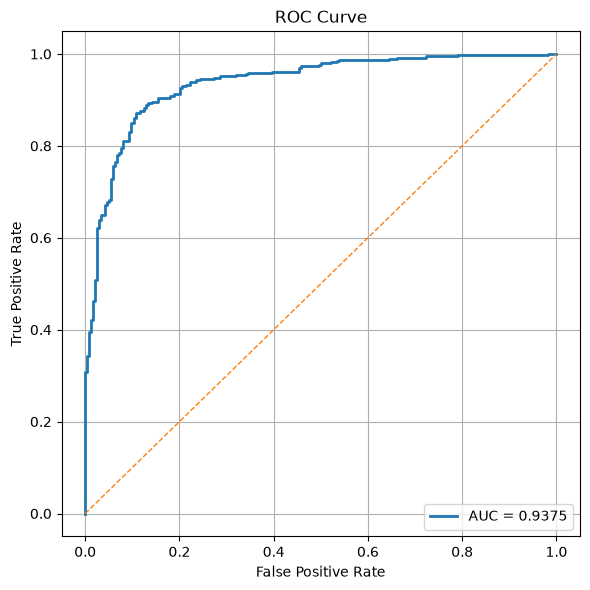

In [13]:
plot_roc_curve(
    results["labels"],
    results["probabilities"],
)

plt.show()

In [15]:
save_predictions_csv(
    filepath="../reports/test_predictions.csv",
    y_true=results["labels"],
    y_pred=results["predictions"],
    probabilities=results["probabilities"],
)

WindowsPath('../reports/test_predictions.csv')

## Conclusion

The trained EfficientNet-B0 model was evaluated on the unseen Chest X-ray
test dataset.

The evaluation included:

- Classification metrics
- Confusion matrix
- ROC curve
- Classification report

These results demonstrate the model's performance on unseen data.

The next notebook introduces Explainable AI (Grad-CAM) to visualize the
regions of the X-ray contributing to the model's predictions.